# Exercício 1

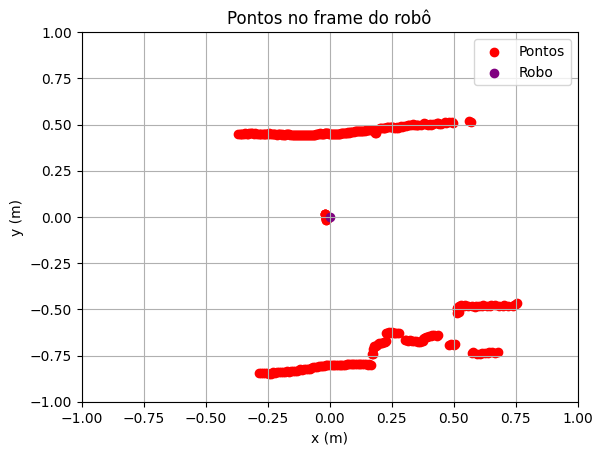

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

from scipy.spatial.transform import Rotation

PLOT_SQUARE_LIM = 1

with open("lidar_info.json", 'r') as file:
    robot = json.load(file)

    angle_min = robot['data']['angle_min']
    angle_max = robot['data']['angle_max']
    angle_increment = robot['data']['angle_increment']

lidar_data = np.loadtxt(
    "lidar_data.csv",
)

points_b = []

for index, px in enumerate(lidar_data):

    new_yaw = angle_min + index * angle_increment

    if (new_yaw <= angle_max):
    
        lidar_yaw = Rotation.from_euler("z", new_yaw, degrees=False)

        lidar_radius  = np.array([px, 0, 0])

        point_b = lidar_yaw.apply(lidar_radius)

        points_b.append(point_b)

points_b = np.array(points_b)

plt.scatter(points_b[:,0], points_b[:,1], color="red", label="Pontos")
plt.scatter(0, 0, color="purple", label="Robo")
plt.title("Pontos no frame do robô")

plt.xlim(-PLOT_SQUARE_LIM, PLOT_SQUARE_LIM)
plt.ylim(-PLOT_SQUARE_LIM, PLOT_SQUARE_LIM)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid()
plt.legend()
plt.show()

# Exercício 2

Assumindo aqui que que o robô está na mesma posição e ângulo que o arquivo da aula ([0.25, 0.30, 0.05] e orientação de 45 graus) por que não tem nada no material da lista. 

Também não entendi qual a função do CSV com dados de uma IMU, uma vez que não fala pra usar nada disso em canto nenhum?

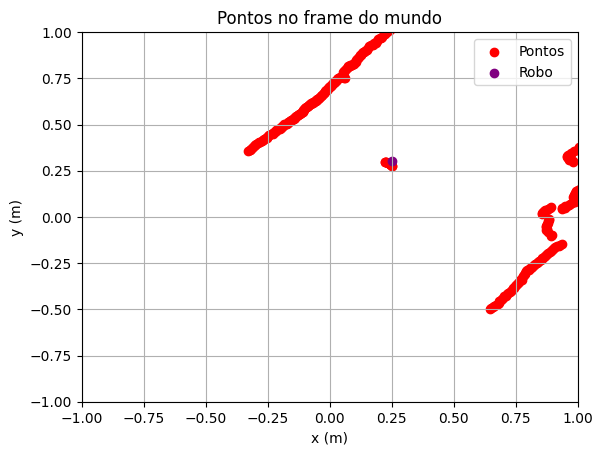

In [67]:
yaw_angle = np.pi/4
robot_pos = np.array([0.25, 0.3, 0.05])

robot_yaw = Rotation.from_euler("z", yaw_angle, degrees=False)

points_w = robot_yaw.apply(points_b)

points_w = points_w + robot_pos

plt.scatter(points_w[:,0], points_w[:,1], color="red", label="Pontos")
plt.scatter(robot_pos[0], robot_pos[1], color="purple", label="Robo")
plt.title("Pontos no frame do mundo")

plt.xlim(-PLOT_SQUARE_LIM, PLOT_SQUARE_LIM)
plt.ylim(-PLOT_SQUARE_LIM, PLOT_SQUARE_LIM)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid()
plt.legend()
plt.show()